In [62]:
import os
import re 
from langchain_groq import ChatGroq
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings.fastembed import FastEmbedEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from langgraph.graph import StateGraph,END,START
from pydantic import BaseModel
from typing import List
from dotenv import load_dotenv
load_dotenv()



True

In [63]:
docs = PyPDFLoader("Machine_learning.pdf").load()

In [14]:
chunks = RecursiveCharacterTextSplitter(chunk_size=1000 , chunk_overlap=200).split_documents(docs)

for d in chunks:
    d.page_content = d.page_content.encode("utf-8","ignore").decode("utf-8","ignore")

In [15]:
len(chunks)

1121

In [16]:
# convert chunks into embeddings 
embeddings = FastEmbedEmbeddings(model="BAAI/bge-small-en-v1.5")

vector_store = FAISS.from_documents(chunks, embeddings)

In [20]:
vector_store.save_local("vectore_store")

In [118]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

## Query Search 

In [119]:
llm = ChatGroq(model="openai/gpt-oss-120b",api_key=os.getenv("GROQ_API_KEY"),temperature=0)

In [120]:
UPPER_TH = 0.7   # isse upar score -> chunk bahut accha
LOWER_TH = 0.3   # isse neeche score -> chunk irrelevant



In [121]:
class State(BaseModel):
    query:str
    docs: List[Document]

    good_docs: List[Document]
    verdict:str
    reason:str

    
    strips:List[str]
    kept_strips:List[str]
    refined_context:str
    answer:str

In [122]:
# retrieve node 
def retrieve(state:State):
    query = state.query

    return {
        "docs": retriever.invoke(query)
    }

# Score based doc evaluator 

class DocEvalScore(BaseModel):
    score:float
    reason:str


doc_eval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only.",
        ),
        ("human", "query:{query}\n\nChunk:\n{chunk}"),
    ]
)

doc_eval_chain = doc_eval_prompt | llm.with_structured_output(DocEvalScore)

def eval_each_doc_node(state: State) -> dict:
    q = state.query

    scores: List[float] = []
    reasons: List[str] = []
    good: List[Document] = []

    for d in state.docs:
        out = doc_eval_chain.invoke({"query": q, "chunk": d.page_content})
        scores.append(out.score)
        reasons.append(out.reason)

        # for CORRECT case we will refine only docs with score > LOWER_TH
        if out.score > LOWER_TH:
            good.append(d)

    # 1) CORRECT: kam se kam ek chunk bahut accha hai
    if any(s > UPPER_TH for s in scores):
        return {
            "good_docs": good,
            "verdict": "CORRECT",
            "reason": f"At least one retrieved chunk scored > {UPPER_TH}.",
        }

    # 2) INCORRECT: koi doc nahi mila, ya sab chunks irrelevant hain
    if len(scores) == 0 or all(s < LOWER_TH for s in scores):
        why = (
            "No chunks retrieved."
            if len(scores) == 0
            else f"All retrieved chunks scored < {LOWER_TH}. " + (reasons[0] if reasons else "")
        )
        return {
            "good_docs": [],
            "verdict": "INCORRECT",
            "reason": why,
        }

    # 3) AMBIGUOUS: beech ka case (na bahut accha, na bilkul bekar)
    return {
        "good_docs": good,
        "verdict": "AMBIGUOUS",
        "reason": f"No chunk scored > {UPPER_TH}, but not all were < {LOWER_TH}. " + (reasons[0] if reasons else ""),
    }
# sentence -level Decomposer

def decompose_to_sentences(text: str) -> List[str]:
    # Extra whitespace (newlines, tabs, multiple spaces) ko single space bana do
    text = re.sub(r"\s+", " ", text).strip()

    # . ! ? ke baad space aaye to wahan se sentence split karo
    sentences = re.split(r"(?<=[.!?])\s+", text)

    # Chhote/faltu fragments (<= 20 chars) hata do
    return [s.strip() for s in sentences if len(s.strip()) > 20]


# Filter (llm judge)
class KeepOrDrop(BaseModel):
    keep:bool

filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system","You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "query: {query}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop)

# refinement Operation  

def refine(state:State) -> dict:
    query = state.query

    # combining retrieve docs into one context string
    context = "\n\n".join(d.page_content for d in state.good_docs).strip()

    # Decompose : context -> sentence strips
    strips = decompose_to_sentences(context)

    # Filter:Keep only relevant strips 
    kept: List[str] = []

    for s in strips:
        if filter_chain.invoke({"query":query, "sentence":s}).keep:
            kept.append(s)

    # recompose : glue kept strips back together (internal Knowledge)
    refined_context ="\n".join(kept).strip()

    return {
        "strips":strips,
        "kept_strips":kept,
        "refined_context":refined_context,
    }

In [123]:
prompt = ChatPromptTemplate.from_messages(
    [
       ("system", "You are a helpful ML tutor. Answer ONLY using the provided refined bullets.\n"
        "if the bullets are empty or insufficient, say: 'I don't know based on the provided books."),
        
       ("human", "query: {query}\n\nrefined_Context:\n{refined_context}"),

    ]
)

In [124]:
def generate(state:State):
    output = (prompt|llm).invoke({"query":state.query, "refined_context":state.refined_context})

    return {
             "answer": output.content
            }


In [125]:
def fail_node(state: State) -> dict:
    return {"answer": f"FAIL: {state.reason}"}


def ambiguous_node(state: State) -> dict:
    return {"answer": f"Ambiguous: {state.reason}"}


def route_after_eval(state: State) -> str:
    if state.verdict == "CORRECT":
        return "refine"
    elif state.verdict == "INCORRECT":
        return "web_search"
    else:
        return "ambiguous"

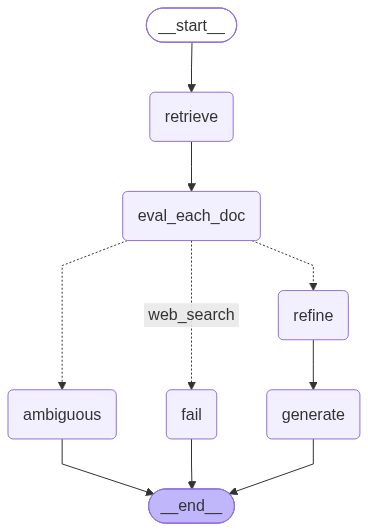

In [126]:
g = StateGraph(State)

g.add_node("retrieve", retrieve)
g.add_node("eval_each_doc", eval_each_doc_node)
g.add_node("refine", refine)
g.add_node("generate", generate)
g.add_node("fail", fail_node)
g.add_node("ambiguous", ambiguous_node)

g.add_edge(START, "retrieve")
g.add_edge("retrieve", "eval_each_doc")

g.add_conditional_edges(
    "eval_each_doc",
    route_after_eval,
    {
        "refine": "refine",
        "web_search": "fail",        # image mein web search ki jagah fail node
        "ambiguous": "ambiguous",
    },
)

g.add_edge("refine", "generate")
g.add_edge("generate", END)
g.add_edge("fail", END)
g.add_edge("ambiguous", END)

app = g.compile()
app

In [127]:
res = app.invoke(
    {
        "query": "What are attention mechanisms and why   are they important in current ML?",
        "docs": [],
        "good_docs": [],
        "verdict": "",
        "reason": "",
        "strips": [],
        "kept_strips": [],
        "refined_context": "",
        "answer": "",
    }
)

print("VERDICT:", res["verdict"])
print("REASON:", res["reason"])
print("\nOUTPUT:\n", res["answer"])

VERDICT: INCORRECT
REASON: All retrieved chunks scored < 0.3. The chunk only contains a syllabus outline about general ML topics and does not mention attention mechanisms or their importance.

OUTPUT:
 FAIL: All retrieved chunks scored < 0.3. The chunk only contains a syllabus outline about general ML topics and does not mention attention mechanisms or their importance.


In [101]:
res = app.invoke({"query": "Explain the bias-variance tradeoff", "docs":[], "strips":[],"kept_strips":[],"refined_context": "", "answer":""})

print(res["answer"])

- Increasing the bias will decrease the variance, and increasing the variance will decrease the bias.  
- Parametric algorithms are generally seen to demonstrate **high bias but low variance**; non‑parametric algorithms demonstrate **low bias and high variance**.  
- The goal of supervised machine learning is to achieve a **balance between bias and variance**.  
- In k‑Nearest Neighbors (kNN), the user‑configurable parameter **k** can be used to trade off bias and variance.  
- **High bias** → low accuracy (predicted values are not close to the real value); this often leads to **underfitting**.  
- **High variance** → low prediction quality (predicted values are scattered); errors arise from differences in training data sets.  
- **Low bias** → high accuracy (predicted values are close to the real value).  
- **Low variance** → predictions are close to each other (high prediction consistency).


In [102]:
# print(res['docs'][0].page_content)
# print('*'*100)
# print(res['docs'][1].page_content)
# print('*'*100)
# print(res['docs'][2].page_content)
# print('*'*100)
# print(res['docs'][3].page_content)


In [103]:
# for i, doc in enumerate(res["docs"]):
#     print(f"--- Doc {i+1} ---")
#     print(doc.page_content)
#     print("*" * 100)